Connected to ni-vedo-env (Python 3.14.0)

 # Notebook 01: Mesh generation from TIFF mask

 **Paper section:** Methods — Neural tube segmentation
 **Paper figures:** Fig. 1c–d (segmented lumen meshes)

 This script converts two binary 3D TIFF segmentation masks (inner lumen and
 outer basal surface) into smoothed, decimated triangulated surface meshes.

 **Pipeline for each mask:**
 1. Load binary TIFF stack (lumen/tissue = 1, background = 0)
 2. Extract raw mesh via marching cubes (`get_mesh`)
 3. Smooth (100 iterations of Laplacian smoothing)
 4. Decimate to 5 % of original face count
 5. Final smooth pass (50 iterations, boundary-preserving)
 6. Save as PLY — `lumen.ply` (inner) and `basal.ply` (outer)

 **Prerequisites:** TIFF masks must already be segmented.
 See `docs/segmentation.md` for the full segmentation workflow
 (Fiji gamma correction → 3D Slicer local thresholding → manual refinement).

 **Input files** (`data/example/`):
 - `2025-10-22-12-30-Inner_Mask.tif`
 - `2025-10-22-12-30-Outer_Mask.tif`

 **Output files** (`data/example/`):
 - `lumen.ply` — inner surface, used by notebooks 02–05
 - `basal.ply`  — outer surface, used by notebook 03 (thickness)

In [ ]:
from vedo import settings
settings.default_backend = "vtk"

from spatchcocking import *
import os

 ## Voxel scaling

 Set the physical voxel dimensions for your microscope acquisition.
 These values scale the mesh from voxel units into µm.

 - `px2umz`  — z-step size (µm per slice)
 - `px2umxy` — in-plane pixel size (µm per pixel)

In [ ]:
scaling = [4.5, 5.535, 5.535]   # [z, xy, xy] in µm

px2umz  = scaling[0]   # z-step size
px2umxy = scaling[1]   # xy pixel size

 ## Set working directory

 `get_mesh` saves intermediate files (`.ply`, `-mesh.stl`) to the current
 working directory.  We move into `data/example/` so all outputs land there.

In [ ]:
data_dir = os.path.abspath("../data/example")
os.chdir(data_dir)
print("Working directory:", os.getcwd())

Working directory: c:\Users\nimes\WorkWorkWork\Playground\2026-03-05-git-spatchcocking\spatchcocking\data\example


 ## Input file paths

In [ ]:
inner_mask_path = "2025-10-22-12-30-Inner_Mask.tif"
outer_mask_path = "2025-10-22-12-30-Outer_Mask.tif"

 ## Process inner (lumen) mask

 `get_mesh` loads the TIFF, runs marching cubes, saves a raw `{namefile}.ply`,
 does a light decimate + subdivide + smooth pass, and returns the mesh.
 We then load the raw `.ply` and apply a heavier smoothing + decimation
 pipeline to produce a clean surface at manageable vertex count.

In [ ]:
namefile = strippathname(inner_mask_path)
print(f"Processing: {namefile}")

mesh_stl = f"{namefile}-mesh.stl"

if os.path.exists(mesh_stl):
    print(f"Loading existing mesh: {mesh_stl}")
    inner_mesh = Mesh(mesh_stl)
else:
    # Generate raw mesh (also saves {namefile}.ply and {namefile}-mesh.stl)
    inner_mesh = get_mesh(inner_mask_path, px2umz, px2umxy)
    print("Raw mesh generated")

Processing: 2025-10-22-12-30-Inner_Mask
Loaded TIFF stack with shape: (462, 768, 1024)
Data type: uint8
Value range: [0, 1]
Preprocessing mask...
Binary mask has 10228203 voxels
Removing small objects...
After cleaning: 10228203 voxels
Filling holes...
After filling holes: 10228216 voxels
Smoothing mask...
After smoothing: 10228216 voxels
Extracting mesh using marching cubes...
Marching cubes result:
  Vertices: 591130
  Faces: 1182256
  Normals: 591130
Mesh saved to: 2025-10-22-12-30-Inner_Mask.ply
Saved: 2025-10-22-12-30-Inner_Mask-mesh.stl
Raw mesh generated


 ### Smooth and decimate inner mesh

 - `smooth(niter=100)` — Laplacian relaxation, 100 passes
 - `decimate(fraction=0.05)` — keep 5 % of original faces
 - `decimate(fraction=0.1).smooth(niter=50, boundary=True)` — final pass

vedo.mesh.core.Mesh
name          : Mesh
file name     : 2025-10-22-12-30-Inner_Mask.ply
elements      : vertices=2,957 polygons=5,910 lines=0
position      : (0, 0, 0)
scaling       : (1.00000, 1.00000, 1.00000)
size          : average=1034.95, diagonal=4605.80
center of mass: (1114.81, 1874.74, 3575.93)
bounds        : x=(189, 1.84e+3), y=(645, 3.31e+3), z=(1.49e+3, 4.86e+3)
metadata      : "decimate_actual_fraction" = [0.0999797]
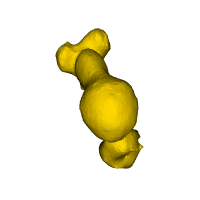

In [ ]:
# Load the raw PLY produced by get_mesh
mesh0 = Mesh(namefile + ".ply")

# Heavy smoothing
mesh1 = mesh0.clone().smooth(niter=100)

# Aggressive decimation
mesh2 = mesh1.clone().decimate(fraction=0.05)

# Final light decimate + boundary-preserving smooth
mesh2.decimate(fraction=0.1).smooth(niter=50, boundary=True)

In [ ]:
# Save final inner mesh — used by all downstream notebooks
mesh2.write("lumen.ply")
print("Saved: lumen.ply")

Saved: lumen.ply


 ## Process outer (basal) mask

 Same pipeline as the inner mask.

In [ ]:
namefile = strippathname(outer_mask_path)
print(f"Processing: {namefile}")

mesh_stl = f"{namefile}-mesh.stl"

if os.path.exists(mesh_stl):
    print(f"Loading existing mesh: {mesh_stl}")
    outer_mesh = Mesh(mesh_stl)
else:
    outer_mesh = get_mesh(outer_mask_path, px2umz, px2umxy)
    print("Raw mesh generated")

Processing: 2025-10-22-12-30-Outer_Mask
Loaded TIFF stack with shape: (462, 768, 1024)
Data type: uint8
Value range: [0, 1]
Preprocessing mask...
Binary mask has 15845615 voxels
Removing small objects...
After cleaning: 15845612 voxels
Filling holes...
After filling holes: 15845804 voxels
Smoothing mask...
After smoothing: 15845804 voxels
Extracting mesh using marching cubes...
Marching cubes result:
  Vertices: 749918
  Faces: 1499876
  Normals: 749918
Mesh saved to: 2025-10-22-12-30-Outer_Mask.ply
Saved: 2025-10-22-12-30-Outer_Mask-mesh.stl
Raw mesh generated


In [ ]:
show(outer_mesh).close()

vedo.plotter.runtime.Plotter
n. of objects : 1
bounds        : x=(1.00, -1.00), y=(1.00, -1.00), z=(1.00, -1.00)
axes style    : [None]

vedo.mesh.core.Mesh
name          : Mesh
file name     : 2025-10-22-12-30-Outer_Mask.ply
elements      : vertices=3,749 polygons=7,498 lines=0
position      : (0, 0, 0)
scaling       : (1.00000, 1.00000, 1.00000)
size          : average=1078.53, diagonal=4814.78
center of mass: (1140.17, 1857.44, 3555.16)
bounds        : x=(139, 1.91e+3), y=(645, 3.35e+3), z=(1.35e+3, 4.92e+3)
metadata      : "decimate_actual_fraction" = [0.099984]
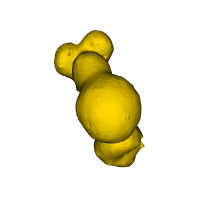

In [ ]:
# Load the raw PLY, smooth and decimate
mesh0 = Mesh(namefile + ".ply")
mesh1 = mesh0.clone().smooth(niter=100)
mesh2 = mesh1.clone().decimate(fraction=0.05)
mesh2.decimate(fraction=0.1).smooth(niter=50, boundary=True)

In [ ]:
# Save final outer mesh — used by notebook 03 (thickness)
mesh2.write("basal.ply")
print("Saved: basal.ply")

Saved: basal.ply


 ## Preview both meshes together

In [ ]:
lumen = Mesh("lumen.ply").c("lightblue").alpha(0.7)
basal  = Mesh("basal.ply").c("salmon").alpha(0.4)

show([lumen, basal], N=2, axes=1).close()

vedo.plotter.runtime.Plotter
n. of objects : 4 (6706 vertices)
bounds        : x=(-224, 1.93e+3), y=(418, 3.36e+3), z=(1.33e+3, 4.94e+3)
axes style    : 1 (default customizable grid walls)

 ## Output summary

 | File | Content | Used by |
 |---|---|---|
 | `lumen.ply` | Inner (lumen) surface mesh | Notebooks 02, 03, 04, 05 |
 | `basal.ply`  | Outer (basal lamina) mesh  | Notebook 03 (thickness)   |

 Pass these paths to the next notebook:
 ```python
 from vedo import Mesh
 lumen_mesh = Mesh("../data/example/lumen.ply")
 basal_mesh  = Mesh("../data/example/basal.ply")
 ```

In [ ]:
lumen = Mesh("lumen.ply").c("lightblue").alpha(0.7)
basal  = Mesh("basal.ply").c("salmon").alpha(0.4)

show(lumen, basal, axes=1).close()

vedo.plotter.runtime.Plotter
n. of objects : 3 (6706 vertices)
bounds        : x=(-224, 1.93e+3), y=(417, 3.36e+3), z=(1.33e+3, 4.94e+3)
axes style    : 1 (default customizable grid walls)

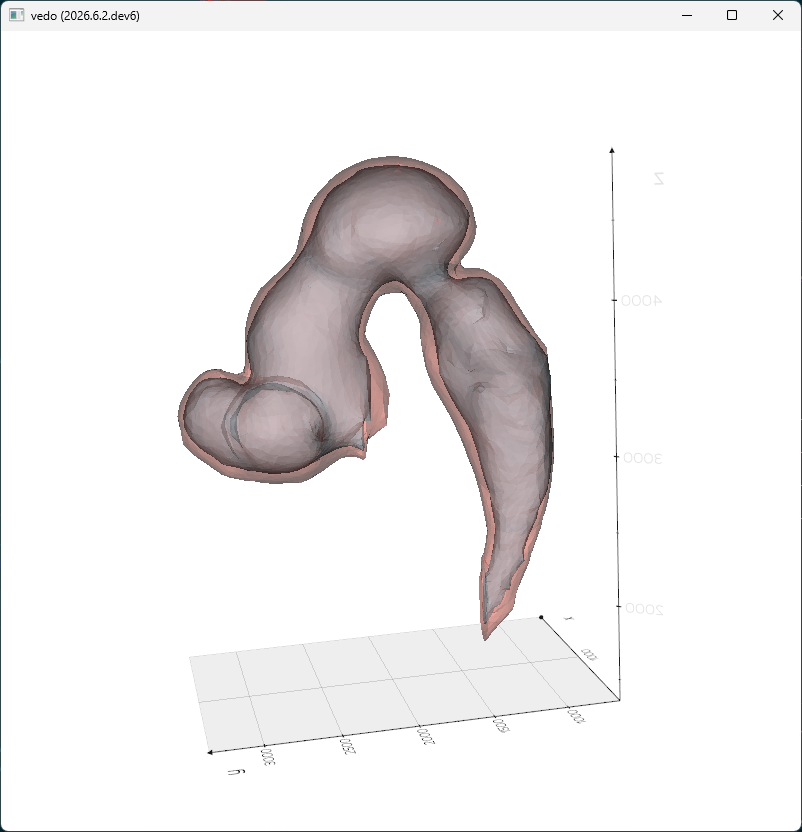